WORK LOG. 

AI usage: 


gitHub notebook: https://github.com/Viktoria0720/IND320_VY/blob/main/ASSIGNMENTS/PART2/notebooks/IND320_VY_v4.ipynb
github streamlit: https://github.com/Viktoria0720/IND320_VY/blob/main/ASSIGNMENTS/PART1/streamlit_app_1/app.py
Streamlit app: https://ind320vy-app1.streamlit.app/

In [10]:
# ---  Imports & plotting defaults ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

from typing import Iterable
from scipy.fft import dct, idct
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.tsa.seasonal import STL
from scipy.signal import spectrogram
from pymongo import MongoClient

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

# Optional: pretty display of wide DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [11]:
# --- Price areas → city centerpoints DataFrame ---

# This maps the five NO price areas to representative cities and their lat/lon.
# Coordinates are approximate city centers

PRICE_AREAS = [
    {"area": "NO1", "city": "Oslo",         "lat": 59.9139,  "lon": 10.7522},
    {"area": "NO2", "city": "Kristiansand", "lat": 58.1467,  "lon": 7.9956},
    {"area": "NO3", "city": "Trondheim",    "lat": 63.4305,  "lon": 10.3951},
    {"area": "NO4", "city": "Tromsø",       "lat": 69.6492,  "lon": 18.9553},
    {"area": "NO5", "city": "Bergen",       "lat": 60.39299, "lon": 5.32415},
]

locations_df = pd.DataFrame(PRICE_AREAS)[["area", "city", "lon", "lat"]]
locations_df

,area,city,lon,lat
0,NO1,Oslo,10.75220,59.91390
1,NO2,Kristiansand,7.99560,58.14670
2,NO3,Trondheim,10.39510,63.43050
3,NO4,Tromsø,18.95530,69.64920
4,NO5,Bergen,5.32415,60.39299


In [12]:
# --- Elhub production 2022–2024: download & prepare (same style as assignment 2) ---

import time
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo  # Python 3.9+

# Matches your assignment2 settings
ELHUB_BASE_URL = "https://api.elhub.no/energy-data/v0/price-areas"
ELHUB_DATASET  = "PRODUCTION_PER_GROUP_MBA_HOUR"

def elhub_format_date(dt_obj: datetime) -> str:
    """
    Format datetime as local Oslo wall time with explicit +02:00 offset,
    URL-encoded as '%2B02:00', like in your assignment2 notebook.
    """
    return dt_obj.strftime("%Y-%m-%dT%H:%M:%S%%2B02:00")

def download_elhub_production(years: list[int]) -> pd.DataFrame:
    """
    Download hourly production for the given list of years using
    PRODUCTION_PER_GROUP_MBA_HOUR and return a tidy DataFrame with columns:
    [priceArea, productionGroup, startTime, quantityKwh]
    """
    all_records: list[dict] = []
    headers = {"Accept": "application/json"}

    for year in years:
        print(f"=== Fetching Elhub {year} (monthly) via startDate/endDate, +02:00 encoded ===")
        for month in range(1, 13):
            start = datetime(year, month, 1)
            next_month = (start + timedelta(days=32)).replace(day=1)
            end = next_month - timedelta(seconds=1)

            start_str = elhub_format_date(start)
            end_str   = elhub_format_date(end)

            url = (
                f"{ELHUB_BASE_URL}"
                f"?dataset={ELHUB_DATASET}&startDate={start_str}&endDate={end_str}"
            )
            print(f"\n→ Fetching {start.date()} → {end.date()}")
            resp = requests.get(url, headers=headers, timeout=60)
            if resp.status_code != 200:
                print(f"  ❌ HTTP {resp.status_code}")
                continue

            raw = resp.json()
            data = raw.get("data", raw) if isinstance(raw, dict) else raw
            if not isinstance(data, list):
                print("  ⚠ Unexpected payload; skipping month")
                continue

            month_rows = 0
            for entry in data:
                attrs = entry.get("attributes", {}) if isinstance(entry, dict) else {}
                price_area = attrs.get("name") or entry.get("name") or "UNKNOWN"
                series = attrs.get("productionPerGroupMbaHour", [])
                if not isinstance(series, list):
                    continue

                for r in series:
                    # Skip placeholder rows
                    if r.get("productionGroup") == "*":
                        continue

                    # Normalize keys like in assignment2
                    pg = (
                        r.get("productionGroup") or
                        r.get("group") or
                        r.get("groupCode")
                    )
                    ts = (
                        r.get("startTime") or
                        r.get("fromTime") or
                        r.get("time") or
                        r.get("datetime") or
                        r.get("start") or
                        r.get("from_time")
                    )
                    qk = (
                        r.get("quantityKwh") or
                        r.get("quantity") or
                        r.get("value") or
                        r.get("kwh") or
                        r.get("amount")
                    )
                    if pg and ts and qk is not None:
                        all_records.append({
                            "priceArea":       price_area,
                            "productionGroup": pg,
                            "startTime":       ts,
                            "quantityKwh":     qk,
                        })
                        month_rows += 1

            print(f"  ✅ {month_rows} rows added")
            time.sleep(1)  # be nice to the API

    print(f"\nTotal raw rows collected: {len(all_records)}")

    df = pd.DataFrame(all_records)
    if df.empty:
        raise RuntimeError("No rows collected from Elhub for requested years.")

    # Parse timestamp; Elhub returns offsets in the strings → tz-aware
    df["startTime"]   = pd.to_datetime(df["startTime"], utc=True, errors="coerce")
    df["quantityKwh"] = pd.to_numeric(df["quantityKwh"], errors="coerce")

    # Convert to Europe/Oslo and filter by *Oslo year* (to match the 2021 logic)
    df_oslo = df.copy()
    df_oslo["startTimeOslo"] = df_oslo["startTime"].dt.tz_convert(ZoneInfo("Europe/Oslo"))
    df_oslo["year_oslo"] = df_oslo["startTimeOslo"].dt.year

    df_multi = df_oslo[df_oslo["year_oslo"].isin(years)].copy()

    # Keep canonical columns; sort
    df_final = (
        df_multi[["priceArea", "productionGroup", "startTime", "quantityKwh"]]
        .sort_values(["priceArea", "startTime"], kind="stable")
        .reset_index(drop=True)
    )

    print("\n=== Summary (downloaded years) ===")
    if not df_final.empty:
        print("Years (Oslo):", sorted(df_multi["year_oslo"].unique()))
        print("Span UTC:", df_final["startTime"].min(), "→", df_final["startTime"].max())
        print("Areas:", df_final["priceArea"].nunique(),
              "| Groups:", df_final["productionGroup"].nunique())
        print("Rows:", len(df_final))
    else:
        print("No rows after filtering for requested years.")

    return df_final

# Actually download 2022–2024 now
YEARS_NEW = [2022, 2023, 2024]
prod_22_24 = download_elhub_production(YEARS_NEW)

# Quick peek
display(prod_22_24.head())


=== Fetching Elhub 2022 (monthly) via startDate/endDate, +02:00 encoded ===

→ Fetching 2022-01-01 → 2022-01-31
  ✅ 15460 rows added

→ Fetching 2022-02-01 → 2022-02-28
  ✅ 14469 rows added

→ Fetching 2022-03-01 → 2022-03-31
  ✅ 16837 rows added

→ Fetching 2022-04-01 → 2022-04-30
  ✅ 16582 rows added

→ Fetching 2022-05-01 → 2022-05-31
  ✅ 17302 rows added

→ Fetching 2022-06-01 → 2022-06-30
  ✅ 16874 rows added

→ Fetching 2022-07-01 → 2022-07-31
  ✅ 17764 rows added

→ Fetching 2022-08-01 → 2022-08-31
  ✅ 17627 rows added

→ Fetching 2022-09-01 → 2022-09-30
  ✅ 16951 rows added

→ Fetching 2022-10-01 → 2022-10-31
  ✅ 16798 rows added

→ Fetching 2022-11-01 → 2022-11-30
  ✅ 15920 rows added

→ Fetching 2022-12-01 → 2022-12-31
  ✅ 16418 rows added
=== Fetching Elhub 2023 (monthly) via startDate/endDate, +02:00 encoded ===

→ Fetching 2023-01-01 → 2023-01-31
  ✅ 16605 rows added

→ Fetching 2023-02-01 → 2023-02-28
  ✅ 15322 rows added

→ Fetching 2023-03-01 → 2023-03-31
  ✅ 17262 rows

,priceArea,productionGroup,startTime,quantityKwh
0,NO1,hydro,2021-12-31 23:00:00+00:00,1291422.400
1,NO1,other,2021-12-31 23:00:00+00:00,0.600
2,NO1,solar,2021-12-31 23:00:00+00:00,6.448
3,NO1,thermal,2021-12-31 23:00:00+00:00,30049.920
4,NO1,wind,2021-12-31 23:00:00+00:00,143012.270


In [13]:
# --- Append production 2022–2024 into Mongo collection used by this notebook ---

MONGO_URI = os.getenv("MONGO_URI", "")

if not MONGO_URI:
    print("⚠️  MONGO_URI is not set; skipping Mongo export. Set it and re-run this cell.")
else:
    if "prod_22_24" not in globals() or prod_22_24.empty:
        raise RuntimeError("prod_22_24 is missing or empty – run the download cell first.")

    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    db = client["energy"]
    client.admin.command("ping")
    print("Connected to MongoDB database:", db.name)

    coll = db["elhub_production_2021"]  # same collection your loader already uses

    # OPTIONAL: clear any existing 2022–2024 docs (safe to rerun this cell)
    coll.delete_many({
        "startTime": {
            "$gte": "2022-01-01T00:00:00Z",
            "$lt":  "2025-01-01T00:00:00Z",
        }
    })

    # Prepare output: ISO-8601 UTC strings with 'Z', same as 2021 export
    df_out = prod_22_24.copy()
    df_out["startTime"] = (
        pd.to_datetime(df_out["startTime"], utc=True, errors="coerce")
          .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    )

    docs = df_out.to_dict(orient="records")

    BATCH = 200_000
    inserted = 0
    for i in range(0, len(docs), BATCH):
        batch = docs[i : i + BATCH]
        if batch:
            coll.insert_many(batch)
            inserted += len(batch)

    print(f"Inserted {inserted} production docs for 2022–2024 into {coll.full_name}")


Connected to MongoDB database: energy
Inserted 606830 production docs for 2022–2024 into energy.elhub_production_2021


In [14]:

# - time: startTime (ISO UTC string)
# - area: priceArea
# - group: productionGroup (e.g., "hydro")
# - production: quantityKwh

def load_elhub_from_mongo_override(
    coll,
    time_field: str = "startTime",
    area_field: str = "priceArea",
    group_field: str = "productionGroup",
    prod_field: str = "quantityKwh",
    year: int | None = 2025,  # change or set None to load all years
) -> pd.DataFrame:
    proj = {"_id": 0, time_field: 1, prod_field: 1}
    if area_field:  proj[area_field]  = 1
    if group_field: proj[group_field] = 1

    rows = list(coll.find({}, proj))
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    rename = {time_field: "time", prod_field: "production"}
    if area_field:  rename[area_field]  = "area"
    if group_field: rename[group_field] = "group"
    df = df.rename(columns=rename)

    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    # convert to Europe/Oslo, drop tz for statsmodels
    df["time"] = df["time"].dt.tz_convert("Europe/Oslo").dt.tz_localize(None)
    df["production"] = pd.to_numeric(df["production"], errors="coerce")

    if year is not None:
        df = df[df["time"].dt.year == year]

    # Clean + nice group casing
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip().str.replace("_", " ").str.title()

    keep = [c for c in ["time","area","group","production"] if c in df.columns]
    return df[keep].dropna(subset=["time","production"]).sort_values("time").reset_index(drop=True)

# --- Connect to Mongo & load ---
MONGO_URI       = os.getenv("MONGO_URI", "mongodb://localhost:27017")
DB_NAME         = "energy"
COLLECTION_NAME = "elhub_production_2021"  

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
client.admin.command("ping")
coll = client[DB_NAME][COLLECTION_NAME]

# Load multiple years and combine: 2021–2024
YEARS_TO_LOAD = [2021, 2022, 2023, 2024]

frames = []

for yr in YEARS_TO_LOAD:
    df_year = load_elhub_from_mongo_override(coll, year=yr)
    if df_year is None or df_year.empty:
        print(f"No data returned for year {yr}")
        continue

    # Optional: explicitly store the year (handy for debugging/plots)
    if "time" in df_year.columns:
        df_year["year"] = df_year["time"].dt.year
    else:
        df_year["year"] = yr

    frames.append(df_year)
    print(f"Loaded {len(df_year)} rows for {yr}")

if frames:
    prod_df = (
        pd.concat(frames, ignore_index=True)
          .sort_values("time")
          .reset_index(drop=True)
    )
    print("\nCombined DataFrame:")
    print(f"Total rows: {len(prod_df)}")
    display(prod_df.head())

    if "time" in prod_df.columns:
        print("Years present:")
        print(prod_df["time"].dt.year.value_counts().sort_index())
else:
    prod_df = pd.DataFrame()
    print("No data loaded for any of the requested years.")



Loaded 183212 rows for 2021
Loaded 199002 rows for 2022
Loaded 202920 rows for 2023
Loaded 204908 rows for 2024

Combined DataFrame:
Total rows: 790042


,time,area,group,production,year
0,2021-01-01,NO3,Solar,19.722,2021
1,2021-01-01,NO3,Wind,259312.200,2021
2,2021-01-01,NO3,Hydro,2836774.000,2021
3,2021-01-01,NO2,Wind,706.206,2021
4,2021-01-01,NO2,Solar,876.556,2021


Years present:
time
2021    183212
2022    199002
2023    202920
2024    204908
Name: count, dtype: int64


Using: NO3 Solar


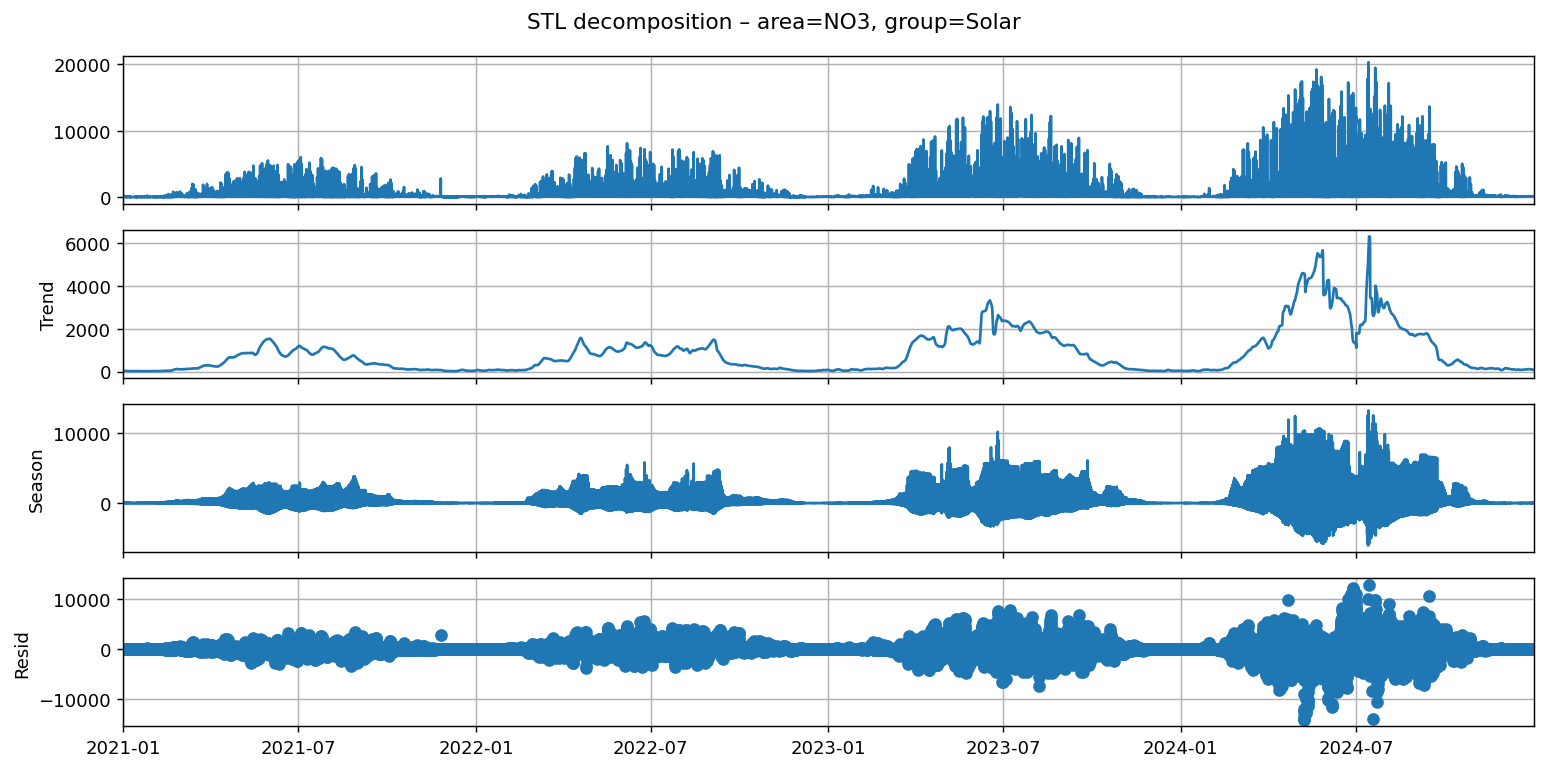

In [15]:
def stl_decompose_production(
    prod_df: pd.DataFrame,
    area: str = "NO5",
    group: str = "Hydro",
    period: int = 24,      # hourly seasonal period; daily data -> 7 or 365
    seasonal: int = 13,
    trend: int = 101,
    robust: bool = True,
):
    """
    Returns (fig, stl_result). Expects columns: time, area, group, production.
    """
    for col in ["time", "production"]:
        if col not in prod_df.columns:
            raise ValueError(f"Missing required column '{col}'")

    df = prod_df.copy()
    if "area" not in df.columns:  df["area"] = area
    if "group" not in df.columns: df["group"] = group

    df = df[(df["area"] == area) & (df["group"] == group)].sort_values("time")
    if df.empty:
        raise ValueError(f"No data for area={area}, group={group}")

    y = pd.Series(df["production"].to_numpy(float), index=pd.to_datetime(df["time"]))
    res = STL(y, period=period, seasonal=seasonal, trend=trend, robust=robust).fit()

    fig = res.plot()
    fig.set_size_inches(12, 6)
    fig.suptitle(f"STL decomposition – area={area}, group={group}")
    fig.tight_layout()
    return fig, res

# Choose existing filters
areas  = prod_df["area"].dropna().unique().tolist() if "area" in prod_df.columns else ["NO1"]
groups = prod_df["group"].dropna().unique().tolist() if "group" in prod_df.columns else ["Hydro"]
AREA_FOR_STL  = areas[0]
GROUP_FOR_STL = groups[0]
print("Using:", AREA_FOR_STL, GROUP_FOR_STL)

# Test
if not prod_df.empty:
    fig_stl, stl_res = stl_decompose_production(
        prod_df,
        area=AREA_FOR_STL,
        group=GROUP_FOR_STL,
        period=24, seasonal=13, trend=101, robust=True
    )
    plt.show()
else:
    print("prod_df is empty; verify Mongo data/year/collection.")


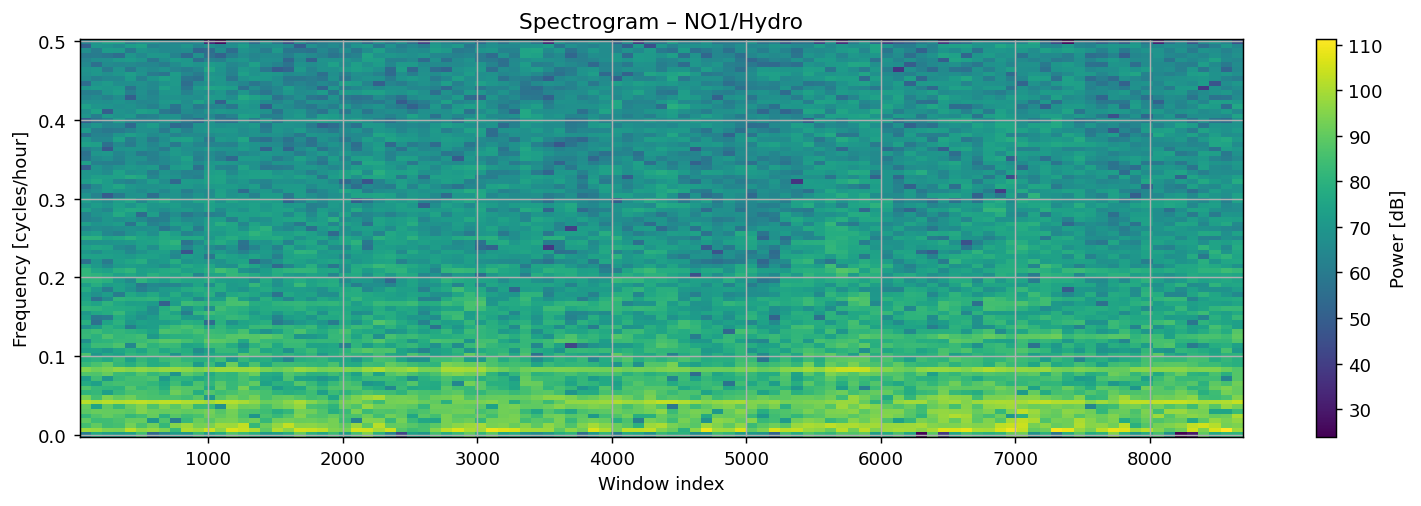

In [21]:
def production_spectrogram(
    prod_df: pd.DataFrame,
    area: str,
    group: str,
    fs: float = 1.0,          # 1 sample per hour
    window_len: int = 7*24,   # one-week window
    overlap: float = 0.5,     # 50% overlap
):
    df = prod_df.copy()
    if "area" not in df.columns:  df["area"] = area
    if "group" not in df.columns: df["group"] = group

    df = df[(df["area"] == area) & (df["group"] == group)].sort_values("time")
    if df.empty:
        raise ValueError(f"No data for area={area}, group={group}")

    x = df["production"].to_numpy(float)
    nperseg = int(window_len)
    noverlap = int(overlap * nperseg)
    f, t, Sxx = spectrogram(x, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling="spectrum")

    fig, ax = plt.subplots()
    im = ax.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading="auto")
    ax.set_title(f"Spectrogram – {area}/{group}")
    ax.set_xlabel("Window index")
    ax.set_ylabel("Frequency [cycles/hour]")
    fig.colorbar(im, ax=ax, label="Power [dB]")
    fig.tight_layout()
    return fig, (f, t, Sxx)

# Test
if not prod_df.empty:
    fig_spec, _ = production_spectrogram(
        prod_df,
        area=AREA_FOR_STL,
        group=GROUP_FOR_STL,
        window_len=24*7,
        overlap=0.5
    )
    plt.show()
else:
    print("prod_df is empty; verify Mongo data/year/collection.")
